# Classification of Japanese Characters

For this lab we will be using KMNIST, which is a variation on the MNIST challenge.  This dataset has 10 Japanese characters from the Kuzushiji alphabet as seen below where the clean/standardized version is on the far left and handwritten variations are along the rows.  

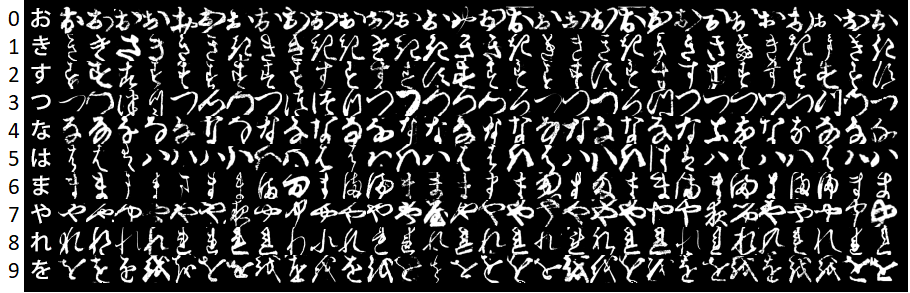

Kuzushiji is basically a cursive way to write Japanese characters, and more common characters actually have more variations than less common characters, which makes them harder to distinguish.  Translations made by experts have been established to take the handwritten characters and map them to modern, standardized versions.  For more, you can read about it here: https://www.tofugu.com/japanese/hentaigana-history-of-japanese-writing-system/

Wouldn't it be nice it this could be automated?  Let's start by loading some libraries...

Please note that this notebook must be run in a "Containerized" Jupyter Notebook on Rosie.  

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

import tensorflow.keras as keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Load and Visualize Data

The data are organized into four files:

* Training images
* Training labels
* Testing images
* Testing labels

These can be loaded with `np.load()`.  This will return a dict-like object with a single key: `arr_0`.  The objects need to be closed when done.

Images are stored as a 3D array: image, rows, columns.

In [ ]:
with np.load("/data/cs2300/L8/kmnist-train-imgs.npz") as training_images_fl:
    print(list(training_images_fl.keys()))
    print(training_images_fl["arr_0"].shape)
    training_images = training_images_fl["arr_0"]
    
with np.load("/data/cs2300/L8/kmnist-test-imgs.npz") as testing_images_fl:
    print(list(testing_images_fl.keys()))
    print(testing_images_fl["arr_0"].shape)
    testing_images = testing_images_fl["arr_0"]
    
with np.load("/data/cs2300/L8/kmnist-train-labels.npz") as training_labels_fl:
    print(list(training_labels_fl.keys()))
    print(training_labels_fl["arr_0"].shape)
    training_labels = training_labels_fl["arr_0"]
    
with np.load("/data/cs2300/L8/kmnist-test-labels.npz") as testing_labels_fl:
    print(list(testing_labels_fl.keys()))
    print(testing_labels_fl["arr_0"].shape)
    testing_labels = testing_labels_fl["arr_0"]

Let's take a look at some of the characters.  

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 10))
for ax, image, label in zip(axes, training_images, training_labels):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title('Class: %i' % label)

## Set up Data for Deep Learning Models

In the following cell, we reshape and prepare the data for training.  The data needs to be in 4D tensors of shape (N,28,28,1) where N is the number of images.  Each image is 28x28 pixels.  Since they are greyscale, the images only have a single channel. 

The tensors represent the 256 possible gray colors using integer values (e.g., 0, 1, 2, …, 255).  You need to convert the tensors to floats by dividing by 255 to scale the pixels to the range of [0, 1].  You should add the lines of code to do this in the area marked TODO below.

In [ ]:
num_classes = 10

# input image dimensions
img_rows, img_cols = 28, 28

x_train = training_images
x_test = testing_images
# Convert class vectors to binary class matrices
y_train = training_labels
y_test = testing_labels

if K.image_data_format() == 'channels_first':
    x_train = x_train.reshape(x_train.shape[0], 1, img_rows, img_cols)
    x_test = x_test.reshape(x_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
    x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)

# TODO

In the following cell, print out the number of training and test samples using x_train and x_test.  Store these values in variables named train_samples and test_samples (respectively).  

In [ ]:
# TODO

## Create the first model

Next we will create a fully connected feed forward neural network (aka. Dense Neural Network (DNN)) model.  You need to add a line of code below to calculate the number of steps per epoch based on the number of training samples and batch size.  

In [ ]:
dnn_epochs = 5
dnn_batch_size = 64

# TODO Calculate steps_per_epoch

dnn_model = Sequential()
dnn_model.add(Flatten())
dnn_model.add(Dense(128, activation='relu'))
dnn_model.add(Dense(128, activation='relu'))
dnn_model.add(Dense(num_classes, activation='softmax'))

dnn_model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(),
              metrics=['accuracy'])

# create the data generator to feed the training with augmentations
datagen = ImageDataGenerator(rotation_range=15,zoom_range=0.02)
datagen.fit(x_train)

## DNN Training

You should then run the next cell with the current hyperparameters, and then experiment with different epoch numbers, batch sizes, and data augmentation (rotation, zoom) to determine what configuration gives a "good" balance of accuracy and performance.  If you are feeling ambitious, you could experiment with the number of hidden dense layers and optimization functions (https://keras.io/api/optimizers/).  Record all your experiments in a table in the lab report document. You should add extra columns to the table if you edit hyperparameters other than what is listed in the provided table. You should run at least 5 different experiments.  

Hints:
- You can determine the model size (total number of parameters) using the .summary() method for each model you create. 
- You can measure the test accuracy using the code below.

After running all your experiments for the DNN, you should create a plot that shows how they trade off performance (training time) vs. test accuracy. Copy this plot into your lab report.

In [ ]:
history = dnn_model.fit(datagen.flow(x_train,training_labels,shuffle=True, batch_size = dnn_batch_size),
                                  steps_per_epoch = steps_per_epoch,
                                  epochs=dnn_epochs)


## Accuracy
In the next cell, we calculate the accuracy of the model against an unseen set of data "test".  Remember, this data was not used in training, so it is a measure of the real-world generalization capability of the model.    

In [ ]:
predicted_probabilities = dnn_model.predict(x_test)
predicted_classes = np.argmax(predicted_probabilities, axis=1)
acc = 100. * accuracy_score(y_test, predicted_classes)
print("Accuracy: {:.2f}%".format(acc))

In [ ]:
#TODO print model summary to get more info (e.g., # parameters) about model we trained

## Confusion Matrix
In the next cell we create a confusion matrix using the "test" data using the most recently fit model.  On the y-axis is the true label and on the x-axis is the predicted label from the model.  Larger counts on the diagonal indicates more correctly classified characters.  

Create the confusion matrix for the classifier with the best set of hyperparameters and copy that matrix into your lab report.

In [ ]:
plt.rcParams["figure.dpi"] = 140
cm = confusion_matrix(y_test, predicted_classes)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5,6,7,8,9])
cmp.plot()
plt.show()

# Create and Evaluate CNN
Next, we create an Convolutional Neural Network (CNN) Model.  Similar to the DNN model, you should calculate the steps_per_epoch below.  

As with the DNN model above, adjust the hyperparameters and data augmentation to try to achieve the best possible accuracy.  You can also try uncommenting the lines below to add some layers to the model to see if that has an effect on training time or accuracy.  Capture all your experiments in the table in the lab document, and copy in the cunfusion matrix from your best performing model.

In [ ]:
%%time
cnn_epochs = 5
cnn_batch_size = 32

# TODO Calculate steps_per_epoch

cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
#cnn_model.add(Dropout(0.25))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
#cnn_model.add(Dense(128, activation='relu'))
#cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(num_classes, activation='softmax'))

# create the data generator to feed the training with augmentations
datagen = ImageDataGenerator(rotation_range=15,zoom_range=0.02)
datagen.fit(x_train)

cnn_model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(),
              metrics=['accuracy'])
history_cnn = cnn_model.fit(datagen.flow(x_train,training_labels,shuffle=True, batch_size = cnn_batch_size),
                                  epochs=cnn_epochs, steps_per_epoch=steps_per_epoch)


In [ ]:
predicted_probabilities = cnn_model.predict(x_test)
predicted_classes = np.argmax(predicted_probabilities, axis=1)

acc = 100. * accuracy_score(y_test, predicted_classes)
cm = confusion_matrix(y_test, predicted_classes)

print("Accuracy: {:.2f}%".format(acc))
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5,6,7,8,9])
cmp.plot()
plt.show()

In the lab report, answer the following questions 

1. Which model (CNN or DNN) achieved the best test accuracy?
Hint: it is possible to achieve better than 95% accuracy on the test set!
2. Which model trained faster?  What is the performance difference between running the slower model on a CPU vs GPU? 
3. Which model was larger (had the most parameters)?  How many parameters did each model have?  Is the number of parameters related to the time it takes to train the model?  
4. Based on your confusion matrices, which class was the most difficult to accurately predict?  Was it consistently difficult among different models?  How can you use the results from the confusion matrix to inform how you would test the mobile app for accuracy?
5. What affect did data augmentation have on the CNN and DNN models?  
6. (Optional) What did you notice when you deployed the models on the Android device? Was the model able to recognize the charaters you tried to write?


## (Optional) Converting the model to TFLite for exporting to Android/iOS

In [ ]:
# TODO make sure you are exporting the right model here!
converter = tf.lite.TFLiteConverter.from_keras_model(cnn_model)
tflite_float_model = converter.convert()

# Show model size in KBs.
float_model_size = len(tflite_float_model) / 1024
print('Float model size = %dKBs.' % float_model_size)

Since this model will be on a mobile device, we want it to small and fast.  **Quantization** is an approach used to shrink ML models. In the following code, we use 8-bit numbers to approximate our 32-bit weights, which shrinks the model size by a factor of 4.

In [ ]:
# Re-convert the model to TF Lite using quantization.
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

# Show model size in KBs.
quantized_model_size = len(tflite_quantized_model) / 1024
print('Quantized model size = %dKBs,' % quantized_model_size)
print('which is about %d%% of the float model size.'\
      % (quantized_model_size * 100 / float_model_size))

Next, we download the TFLite model to be used in the mobile device!

In [ ]:
# Save the quantized model to file to the Downloads directory
f = open('kmnist.tflite', "wb")
f.write(tflite_quantized_model)
f.close()

print('`kmnist.tflite` has been downloaded')

This notebook was originally created by RJ Nowling and modified by Derek Riley and Gabe Wright